In [1]:
import datetime
start_time = datetime.datetime.now()
print('start at', start_time)

start at 2024-06-09 21:00:12.481052


In [2]:
import pandas
from typing import List, Any
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
fulldf = pandas.read_csv('train.csv')

In [ ]:
fulldf

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


# Scope Selection

It would be very computational heavy to process all 100,000 time series with a single MacBook and limited time of the take-home assignment. We will choose to to solve only a subset of the problem.

There is a hierarchy in this problem, for exmaple, there are many time series under the same item, same item class. There are 2 approaches to tackle the problem
- Top-down approach: this will let us study the relationship between factors in the hierachy at the high level. It also allow us to handle time series with low data by exploting the hierarhical properties.
- Bottom-up approach: this will let us study deeply how to handle issues in a case-by-case basis. if we need to process 100,000 time series, we and iterate automatically later.

We will choose the bottom up approach in this notebook for ease of computing and to show to handle issues deeply

In [ ]:
fulldf.set_index(['item_nbr', 'store_nbr'], inplace=True)

(                   id  unit_sales onpromotion
 date                                         
 2014-04-01   21700431        15.0       False
 2014-04-02   21751452        15.0       False
 2014-04-03   21801416         9.0       False
 2014-04-04   21851328        13.0       False
 2014-04-05   21904338        37.0       False
 ...               ...         ...         ...
 2017-08-11  125058830        24.0       False
 2017-08-12  125164123        17.0       False
 2017-08-13  125269808        21.0       False
 2017-08-14  125373927        16.0       False
 2017-08-15  125476811         8.0       False
 
 [1227 rows x 3 columns],
 (1227, 3))

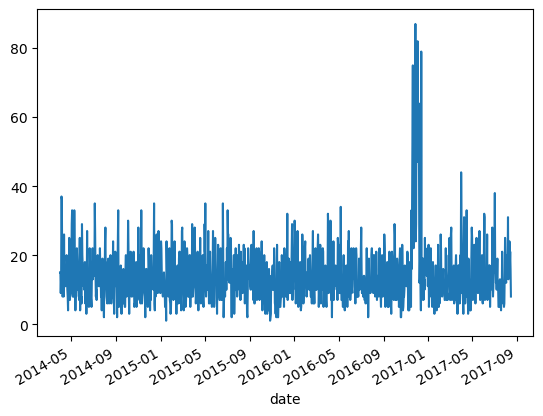

In [ ]:
# idx = (df.index.get_level_values('item_nbr') == 103665) & (df.index.get_level_values('store_nbr') == 25) # hard
idx = (fulldf.index.get_level_values('item_nbr') == 313641) & (fulldf.index.get_level_values('store_nbr') == 46)
idx = idx & ((fulldf.onpromotion == False) | (fulldf.onpromotion == True))

sampledf = fulldf.loc[idx, ].copy()
sampledf.set_index('date', inplace=True)
# the index is str now. make it date
sampledf.index = pandas.to_datetime(sampledf.index)

# cast unit_sales to float
sampledf.unit_sales = sampledf.unit_sales.astype(float)

# filter on upto 2016
# sampledf = sampledf.loc[sampledf.index < '2017-01-01', ].copy()

# plot
sampledf.unit_sales.plot()

sampledf, sampledf.shape

In [ ]:
sampledf.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1227 entries, 2014-04-01 to 2017-08-15
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1227 non-null   int64  
 1   unit_sales   1227 non-null   float64
 2   onpromotion  1227 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 38.3+ KB


In [ ]:
sampledf.sort_index(inplace=True)

# Start Filling Date Gap

In [ ]:
# check date gaps
# add a column days since last
sampledf['date_jump'] = sampledf.index.to_series().diff().dt.days - 1
sampledf.date_jump.value_counts()

date_jump
0.0    1220
1.0       6
Name: count, dtype: int64

In [ ]:


# group by year month then sum date_jump. show only the ones with date_jump > 0
print(sampledf.groupby([sampledf.index.year, sampledf.index.month]).date_jump.sum().loc[lambda x: x > 0])

# also sum all date_jump in the dataset and calculate % to total rows
print('date gap count', sampledf.date_jump.sum(), sampledf.date_jump.sum() / sampledf.shape[0], '%')

date  date
2014  12      1.0
2015  1       1.0
      12      1.0
2016  1       1.0
      12      1.0
2017  1       1.0
Name: date_jump, dtype: float64
date gap count 6.0 0.004889975550122249 %


In [ ]:
# add column unit_sales moving average 7 days, not include today (i.e. lag 1)
sampledf['unit_sales_ma7_lag1'] = sampledf.unit_sales.rolling(window=7).mean().shift(1)
sampledf['unit_sales_ma30_lag1'] = sampledf.unit_sales.rolling(window=30).mean().shift(1)

In [ ]:
# count different values of onpromotion
sampledf.groupby('onpromotion').size()

onpromotion
False    1205
True       22
dtype: int64

In [ ]:
# create series of all dates between min and max date
date_range = pandas.date_range(sampledf.index.min(), sampledf.index.max())
# filter only dates that are not in the original dataset
missing_dates = date_range.difference(sampledf.index)

# create a new dataframe. index = date. onpromotion = False. unit_sales = unit_sales_ma7_lag1 from the date closest before
missingdf = pandas.DataFrame(index=missing_dates)
missingdf['onpromotion'] = False
# create unit_sales column by finding the closest date before in the original dataset
missingdf['unit_sales'] = 0.0
for date in missingdf.index:
    closest_date = sampledf.index[sampledf.index <= date].max()
    missingdf.loc[date, 'unit_sales'] = sampledf.loc[closest_date, 'unit_sales']

# append missingdf to sampledf
# don't use df.append method because AttributeError: 'DataFrame' object has no attribute 'append'

sampledf = pandas.concat([sampledf, missingdf], sort=True)
sampledf.sort_index(inplace=True)


In [ ]:
# check date gaps
# add a column days since last
sampledf['date_jump'] = sampledf.index.to_series().diff().dt.days - 1
sampledf.date_jump.value_counts()

date_jump
0.0    1232
Name: count, dtype: int64

<Axes: >

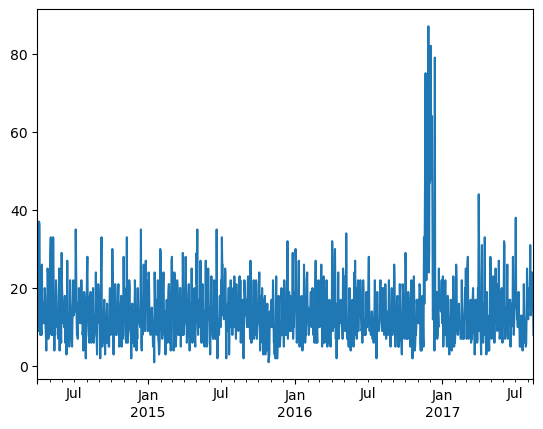

In [ ]:
sampledf.unit_sales.plot()

# Preparing Oil Data

In [ ]:
# load oil.csv
oil = pandas.read_csv('oil.csv')
oil.date = pandas.to_datetime(oil.date)
oil.set_index('date', inplace=True)
oil.sort_index(inplace=True)

In [ ]:
# check missing values in oil
oil.isnull().sum()

dcoilwtico    43
dtype: int64

<Axes: xlabel='date'>

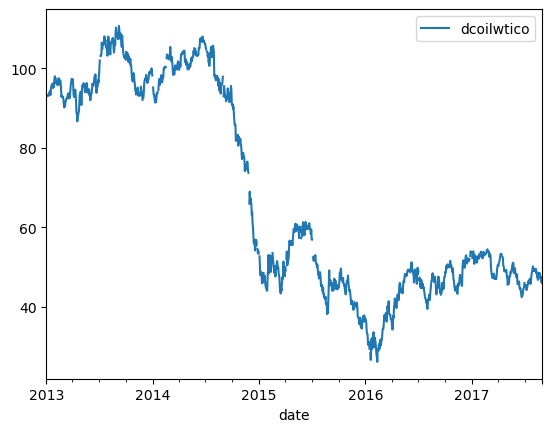

In [ ]:
oil.plot()

In [ ]:
# fill missing dcoilwtico with previous value
# oil.dcoilwtico.fillna(method='ffill', inplace=True)

mindate = min(sampledf.index.min(), oil.index.min())
maxdate = max(sampledf.index.max(), oil.index.max())
alldates = pandas.date_range(mindate, maxdate)
# all dates not in oil
missingdates = alldates.difference(oil.index)

# create a new dataframe. index = date. dcoilwtico = dcoilwtico from the date closest before
missingdf = pandas.DataFrame(index=missingdates)
missingdf['dcoilwtico'] = None

# concat back to oil
oil2 = pandas.concat([oil, missingdf], sort=True)
oil2.sort_index(inplace=True)
oil2.dcoilwtico.fillna(method='ffill', inplace=True)
oil2.dcoilwtico.fillna(method='bfill', inplace=True)

/var/folders/x_/rd78sz7s181dgnvygzmgz0b40000gn/T/ipykernel_77574/2632610076.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  oil2 = pandas.concat([oil, missingdf], sort=True)
/var/folders/x_/rd78sz7s181dgnvygzmgz0b40000gn/T/ipykernel_77574/2632610076.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on

<Axes: >

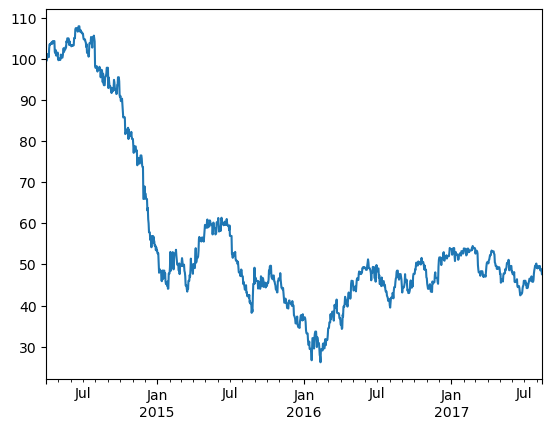

In [ ]:
# merge oil2 to sampledf
sampledf = sampledf.join(oil2, how='left')
sampledf.dcoilwtico.plot()

In [ ]:
sampledf.loc['2016-12-25']

date_jump                 0.0
id                        NaN
onpromotion             False
unit_sales               15.0
unit_sales_ma30_lag1      NaN
unit_sales_ma7_lag1       NaN
dcoilwtico              52.01
Name: 2016-12-25 00:00:00, dtype: object

# Enrich other fields

In [ ]:
# add column unit_sales moving average 7 days, not include today (i.e. lag 1)
sampledf['unit_sales_ma7_lag1'] = sampledf.unit_sales.rolling(window=7).mean().shift(1)
sampledf['unit_sales_ma30_lag1'] = sampledf.unit_sales.rolling(window=30).mean().shift(1)

In [ ]:
# create column onpromotionnum if onpromotion is "True" then 1, "False" then -1, "NaN" then 0
import math
sampledf['onpromotionnum'] = sampledf['onpromotion'].map({True: 1, False: -1, math.nan: 0})

In [ ]:
# day of month
for i in range(1, 32):
    sampledf['dom' + str(i)] = (sampledf.index.day == i).astype(int)

# day of week
for i in range(7):
    sampledf['dow' + str(i)] = (sampledf.index.weekday == i).astype(int)

# month of year
for i in range(1, 13):
    sampledf['moy' + str(i)] = (sampledf.index.month == i).astype(int)

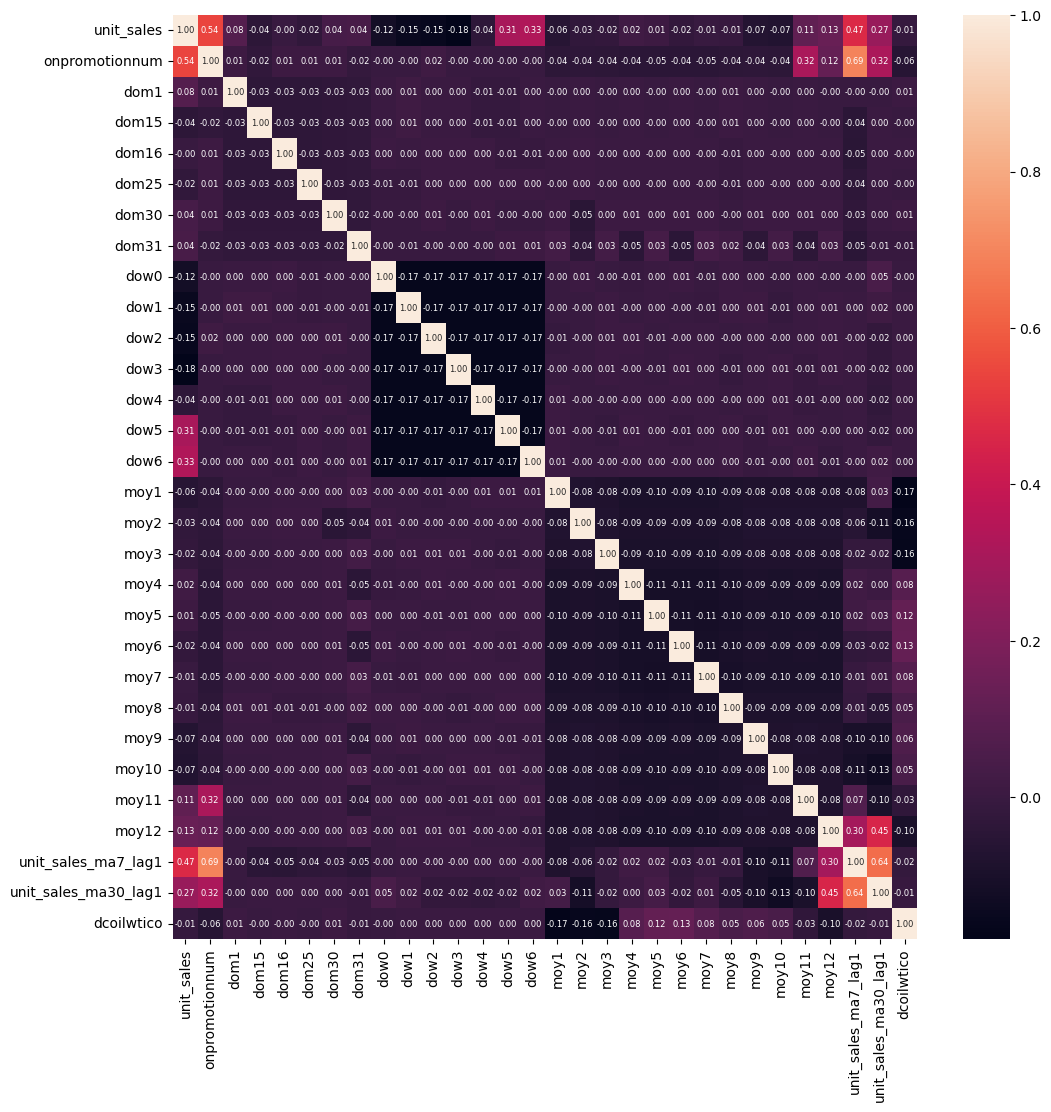

In [ ]:
columns = [
    'unit_sales',
    'onpromotionnum',
    'dom1',
    # 'dom2', 'dom3', 'dom4', 'dom5', 'dom6', 'dom7', 'dom8', 'dom9', 'dom10',
    # 'dom11', 'dom12', 'dom13', 'dom14',
    'dom15', 'dom16',
    # 'dom17', 'dom18', 'dom19', 'dom20',
    # 'dom21', 'dom22', 'dom23', 'dom24',
    'dom25',
    # 'dom26', 'dom27', 'dom28', 'dom29',
    'dom30', 'dom31',
    'dow0', 'dow1', 'dow2', 'dow3', 'dow4', 'dow5', 'dow6',
    'moy1', 'moy2', 'moy3', 'moy4', 'moy5', 'moy6', 'moy7', 'moy8', 'moy9', 'moy10', 'moy11', 'moy12',

    'unit_sales_ma7_lag1',
    'unit_sales_ma30_lag1',

    'dcoilwtico'
]

corr = sampledf[columns].corr()



plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={"size": 6})
plt.show()


<Axes: title={'center': 'unit_sales'}, xlabel='dow'>

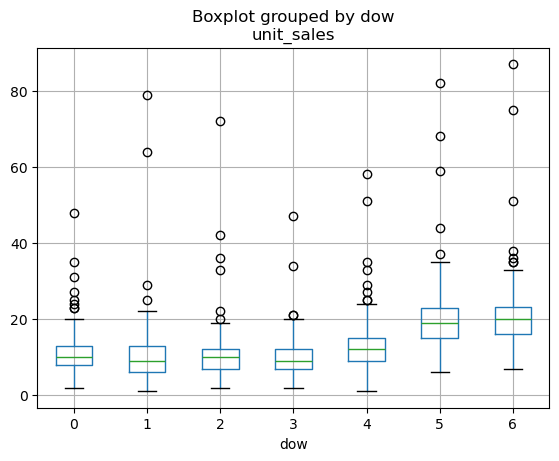

In [ ]:
sampledf['dow'] = sampledf.index.weekday
sampledf.boxplot(column='unit_sales', by='dow')

<Axes: title={'center': 'unit_sales'}, xlabel='[onpromotion]'>

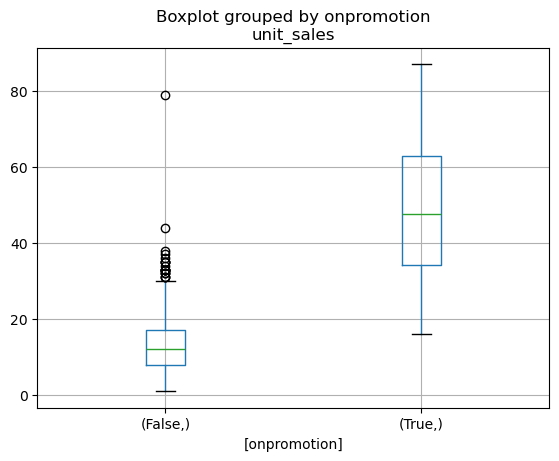

In [ ]:
# boxplot of unit_sales by dow and onpromotion
sampledf.boxplot(column='unit_sales', by=[ 'onpromotion'])


<Axes: title={'center': 'unit_sales'}, xlabel='moy'>

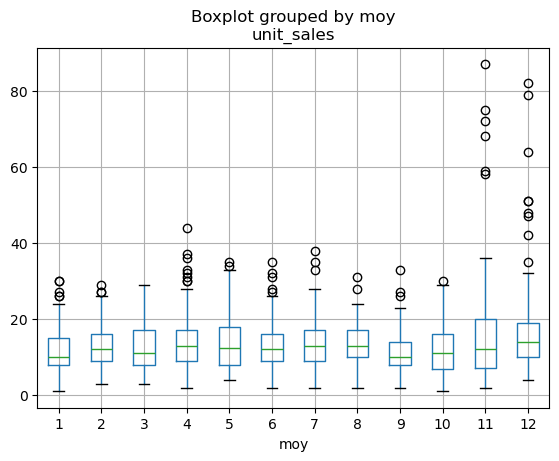

In [ ]:
sampledf['moy'] = sampledf.index.month
# boxplot of unit_sales by dow
sampledf.boxplot(column='unit_sales', by='moy')

<Axes: xlabel='dcoilwtico', ylabel='unit_sales'>

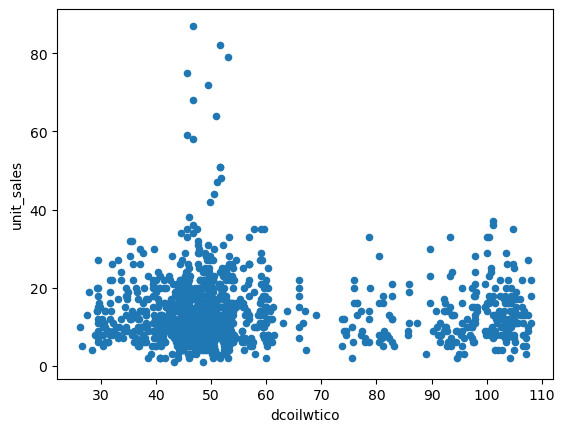

In [ ]:
# scatter unit_sales vs dcoilwtico
sampledf.plot.scatter(x='dcoilwtico', y='unit_sales')


# Examining The Late 2016 Spike Period

DatetimeIndex(['2016-11-16', '2016-11-18', '2016-11-19', '2016-11-20',
               '2016-11-21', '2016-11-23', '2016-11-24', '2016-11-25',
               '2016-11-26', '2016-11-27', '2016-11-30', '2016-12-01',
               '2016-12-02', '2016-12-03', '2016-12-04', '2016-12-05',
               '2016-12-06', '2016-12-07', '2016-12-13'],
              dtype='datetime64[ns]', freq=None)

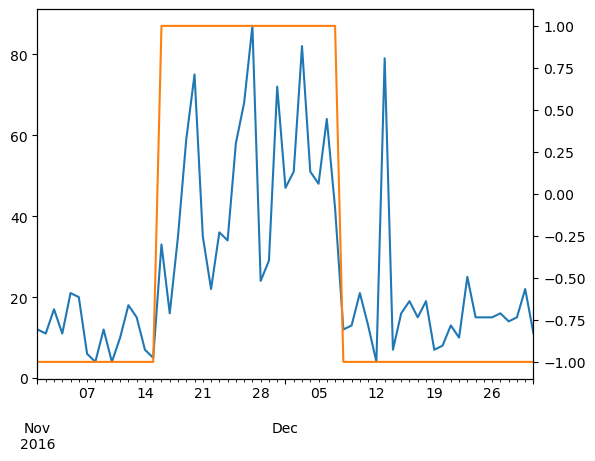

In [ ]:
# sampledf during 2016-11 2016-12
sampledf['2016-11':'2016-12'].unit_sales.plot()
sampledf['2016-11':'2016-12'].onpromotionnum.plot(secondary_y=True)

# sampledf['2016-11':'2016-12'] where unit_sales > 30
sampledf['2016-11':'2016-12'].loc[sampledf.unit_sales > 30, ].index

In [ ]:
# assign the period column for grouping later
sampledf['period'] = '1before'
sampledf.loc['2016-11-16':'2016-12-15', 'period'] = '3spike'
sampledf.loc['2016-12-16':, 'period'] = '4after'
sampledf.loc['2016-04-16':'2016-04-22', 'period'] = '2quake'

In [ ]:
# compare the distribution of many columns in each period
compare_columns = [
    'unit_sales',
    'onpromotionnum',
    'dcoilwtico',
]
sampledf.groupby('period')[compare_columns].describe()

unit_sales                                                       \
             count       mean        std  min    25%   50%    75%   max   
period                                                                    
1before      953.0  13.067156   6.523527  1.0   8.00  12.0  17.00  37.0   
2quake         7.0  13.000000   5.507571  7.0  10.00  12.0  14.00  24.0   
3spike        30.0  41.100000  24.284733  4.0  21.25  35.5  58.75  87.0   
4after       243.0  13.419753   6.823993  3.0   8.50  12.0  17.00  44.0   

        onpromotionnum            ...           dcoilwtico             \
                 count      mean  ...  75%  max      count       mean   
period                            ...                                   
1before          953.0 -1.000000  ... -1.0 -1.0      953.0  58.924218   
2quake             7.0 -1.000000  ... -1.0 -1.0        7.0  41.440000   
3spike            30.0  0.466667  ...  1.0  1.0       30.0  48.974000   
4after           243.0 -1.000000  ... -1.0 -1.0      243.0  49.678765   

                                                        
               std    min    25%    50%    75%     max  
period                                                  
1before  23.112819  26.19  44.33  49.00  74.04  107.95  
2quake    1.400904  39.74  40.40  40.88  42.74   43.18  
3spike    2.691475  45.29  46.72  49.63  51.51   52.99  
4after    3.134765  42.48  47.30  49.58  52.54   54.48  

[4 rows x 24 columns]

The mean unit_sales seems to be the same for all the periods, except the spike period.

But we see a clear difference of "onpromotion" between the periods. The spike period has the highest onpromotion rate.

Let's visualize it more

<Axes: title={'center': 'unit_sales'}, xlabel='[period, onpromotionnum]'>

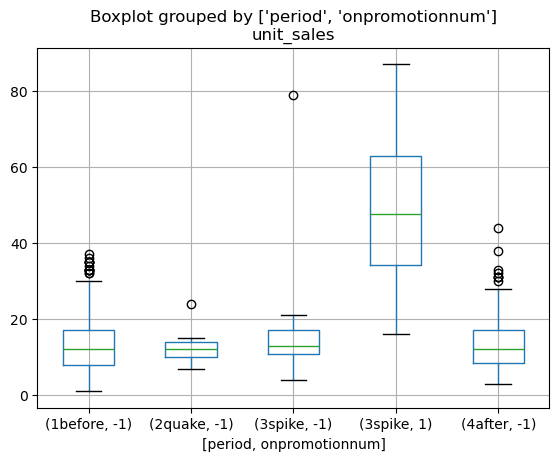

In [ ]:
# boxplot of unit_sales by onpromotionnum and period
sampledf.boxplot(column='unit_sales', by=['period', 'onpromotionnum'])

<Axes: title={'center': 'dcoilwtico'}, xlabel='[period]'>

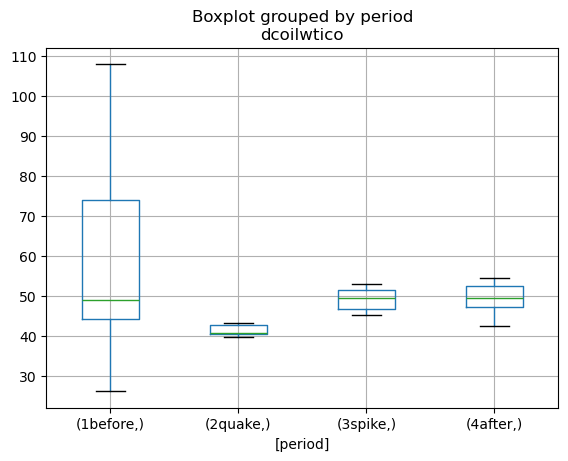

In [ ]:
sampledf.boxplot(column='dcoilwtico', by=['period'])

<Axes: title={'center': 'onpromotionnum'}, xlabel='[period]'>

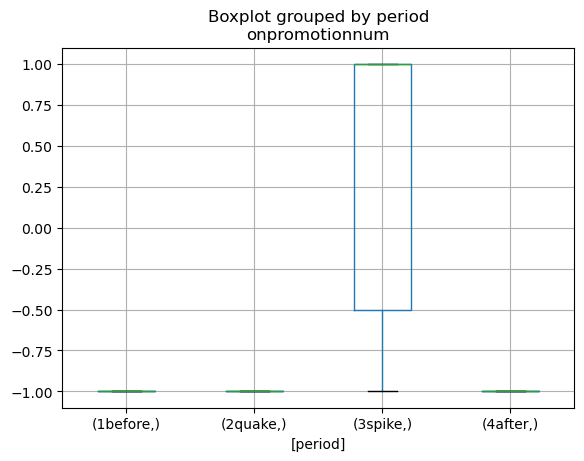

In [ ]:
sampledf.boxplot(column='onpromotionnum', by=['period'])

Let's explore the feature cross correlation matrix again after removing the spike period

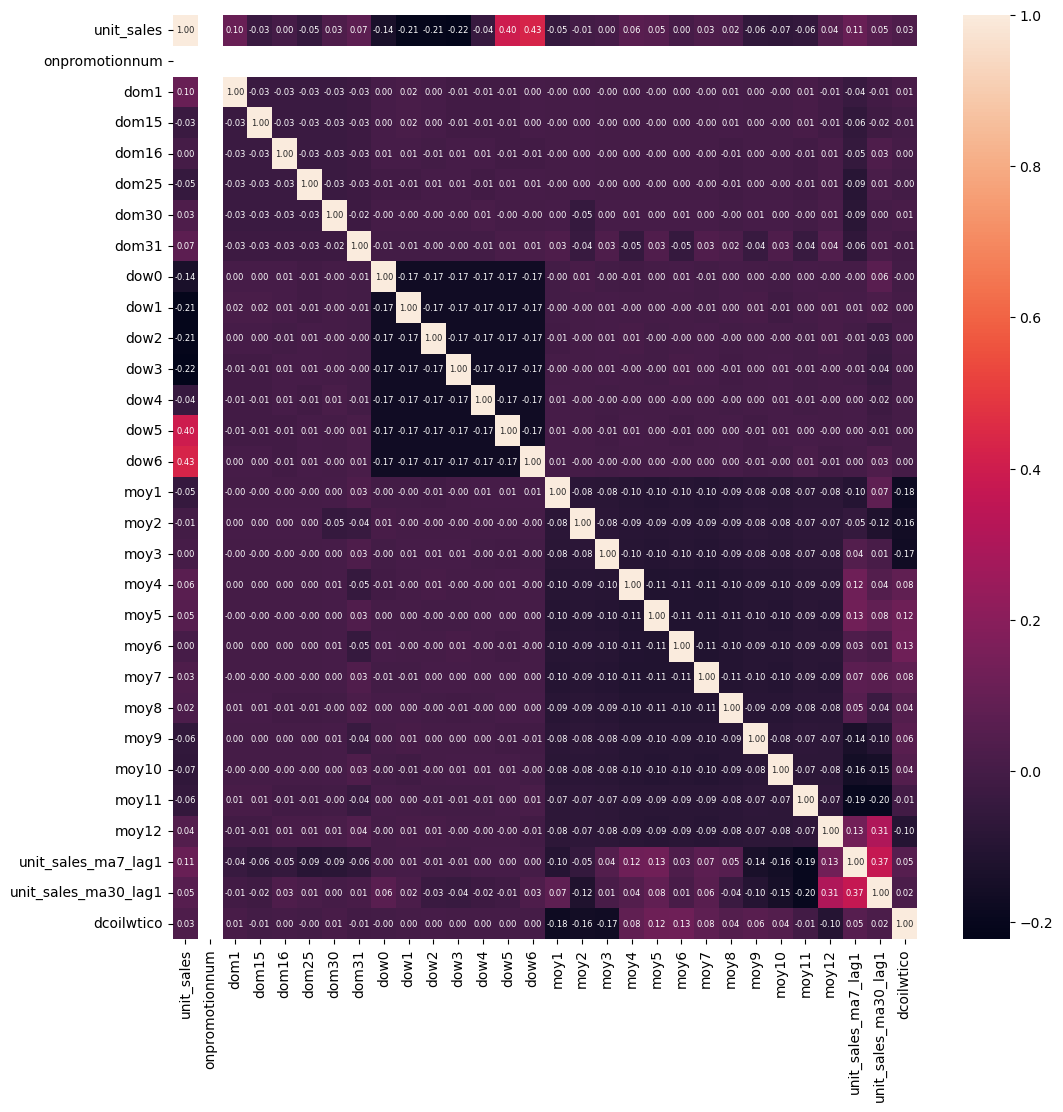

In [ ]:
# do correlation cross matrix heat map
columns = [
    'unit_sales',
    'onpromotionnum',
    'dom1',
    # 'dom2', 'dom3', 'dom4', 'dom5', 'dom6', 'dom7', 'dom8', 'dom9', 'dom10',
    # 'dom11', 'dom12', 'dom13', 'dom14',
    'dom15', 'dom16',
    # 'dom17', 'dom18', 'dom19', 'dom20',
    # 'dom21', 'dom22', 'dom23', 'dom24',
    'dom25',
    # 'dom26', 'dom27', 'dom28', 'dom29',
    'dom30', 'dom31',
    'dow0', 'dow1', 'dow2', 'dow3', 'dow4', 'dow5', 'dow6',
    'moy1', 'moy2', 'moy3', 'moy4', 'moy5', 'moy6', 'moy7', 'moy8', 'moy9', 'moy10', 'moy11', 'moy12',

    'unit_sales_ma7_lag1',
    'unit_sales_ma30_lag1',

    'dcoilwtico'
]

df = sampledf.loc[sampledf.period != '3spike', ]
corr = df[columns].corr()


plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={"size": 6})
plt.show()


We see that `moy11` and `moy12` correlation to `unit_sales` become close to 0 now after removing the spike period from the data

## EDA Summary

- There is a notable correlation between day-of-week and unit sales. A weekly seasonality is implied
- The day-of-month has very low correlation to unit sales. A monthly seasonality is not implied.
- The month-of-year has very low correlation to unit sales. A yearly seasonality is not implied.
- Earthquake 2016-04-16
    - The earthquake 2016-04-16 doesn't has visible effect on unit sales
    - &#x26A1; _Action:_ We choose to not exclude this period from training and evaluation. This will provide a big contiguous data that will benefits ease of processing and model quality
- The Spike 2016-11-16 - 2016-12-13
    - The the spike of unit sales 2016-11-16 - 2016-12-13 is the only period the product is on promotion
    - There is no visible structural change of unit sales after the surge
    - &#x26A1; _Action:_
     Including of the spike time period in training is beneficial because it provide the knowledge of the effect of promotion while there is no visible paradigm change after the period
    - &#x26A1; _Action:_ Since promotion is clearly tied to the surge of unit sales, we can choose to assume that onpromotion = False during 2013 and fill the missing onpromotion in that period as such


# Modeling and Evalaution

## Modeling
We will choose SARIMAX because
- it's designed to handle time series forecasting
- it's designer to handle seasonality
- it can utilize exogeneous variables.

We will also use XGBoost.
- It allows us to use all the features we have engineered
    - even a feature of a very long time period that SARIMAX find challenging to compute.
- XGBoost can also capture non-linear relationships.
- XGBoost is fast to compute and suitable for the time limit and computing resources available of this take-home assignment.

We will do hyper parameter tuning.
- Auto ARIMA is used for SARIMAX
- GridSearchCV is used for XGBoost.

Finally we will ensemble both models using simple average.

## Evaluation
### Metrics:
- RMSE is used because it's easy to interpret and widely used.
- RMSPE is used because it's comparable across different scales in different products. However, it's not prioritized as RMSE here.

### Baseline
Aside from SARIMAX and XGBoost, we will also compare the metrics with a dummy 30-day-moving-average model as a baseline.
It's to see the benefit of our models over not-predicting-at-all.

### Train/Test Split
- We will do cross validation with 3 folds to lessen the risk of overfitting.
    - 3 folds is used because we only has 4 years of data, which is not big.
        - Ideally, the training data should be 4+ times of possible seasonality in training data to let the models learn effectively
        - Test data should also cover an entire year to reflect the effect of possible yearly seasonality.
- The cross validation is using sliding time window, not random sampling, suitable for time series forecasting.



# Cross Validation Train/Validation/Test Split

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3, )

cv_splits = []
for index, (train_index, test_index) in enumerate(tscv.split(sampledf)):
    validation_size = int(len(train_index) * 0.3)

    item = {
        'fold': index,
        'train_index': train_index,
        'test_index': test_index,
        'tuning_train_index': train_index[:-validation_size],
        'tuning_validation_index': train_index[-validation_size:],
    }
    cv_splits.append(item)

    print(
        '| train',
        item['train_index'].min(),
        '-',
        item['train_index'].max(),
        'size',
        len(item['train_index']),
        '| test',
        item['test_index'].min(),
        '-',
        item['test_index'].max(),
        'size',
        len(item['test_index']),
        '| tuning train',
        item['tuning_train_index'].min(),
        '-',
        item['tuning_train_index'].max(),
        'size',
        len(item['tuning_train_index']),
        '| validation',
        item['tuning_validation_index'].min(),
        '-',
        item['tuning_validation_index'].max(),
        'size',
        len(item['tuning_validation_index']),
    )

# cv_splits
train_df = sampledf.loc[sampledf.index[cv_splits[-1]['train_index']]]
test_df = sampledf.loc[sampledf.index[cv_splits[-1]['test_index']]]
tuning_train_df = sampledf.loc[sampledf.index[cv_splits[-1]['tuning_train_index']]]
tuning_validation_df = sampledf.loc[sampledf.index[cv_splits[-1]['tuning_validation_index']]]

| train 0 - 308 size 309 | test 309 - 616 size 308 | tuning train 0 - 216 size 217 | validation 217 - 308 size 92
| train 0 - 616 size 617 | test 617 - 924 size 308 | tuning train 0 - 431 size 432 | validation 432 - 616 size 185
| train 0 - 924 size 925 | test 925 - 1232 size 308 | tuning train 0 - 647 size 648 | validation 648 - 924 size 277


# SARIMAX algorithm

### The SARIMAX Pre-Conditions
SARIMAX model has several assumptions before it can work

- Stationarity: Mean and variance do not change over time.
    - If it doesn't hold true, we need to transform the data to make it stationary
- No Autocorrelation of Residuals: The residuals should not be correlated with each other.
- Normality of Residuals: The residuals should be normally distributed.
- No Multicollinearity (for exogenous variables): If exogenous variables are included, they should not be highly correlated with each other.

We will examine these conditions before fitting the model and transform the data as needed.

### Checking Stationarity

The first thing we need to do SARIMAX (or any time series linear regression models), is to check stationarity of the data.

A Dicky-Fuller Test is used for this

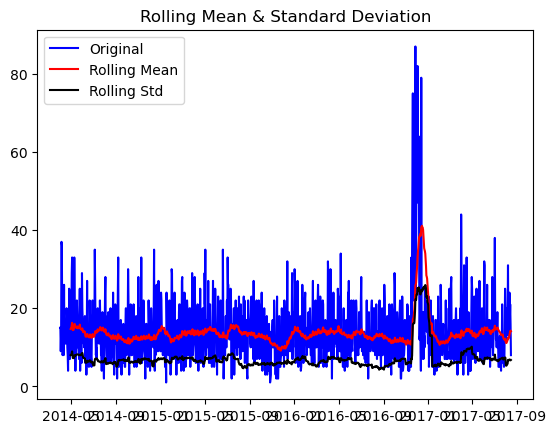

Results of Dickey-Fuller Test:
Test Statistic                -6.706927e+00
p-value                        3.764581e-09
#Lags Used                     2.300000e+01
Number of Observations Used    1.209000e+03
Critical Value (1%)           -3.435770e+00
Critical Value (5%)           -2.863934e+00
Critical Value (10%)          -2.568044e+00
dtype: float64
Is the time series stationary? True


In [ ]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries: pandas.Series) -> bool:
    window_size = 30
    # Determing rolling statistics
    rolmean = timeseries.rolling(window=window_size, center=False).mean()
    rolstd = timeseries.rolling(window=window_size, center=False).std()

    # Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pandas.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

    # print the final line yes no whether it's stationary or not
    is_stationary = dftest[1] < 0.05

    
    return is_stationary

is_stationary = test_stationarity(sampledf['unit_sales'])
print('Is the time series stationary? {0}'.format(is_stationary))

So the data is stationary. We don't need to transform the data to make it stationary.

### Seasonal Decomposition

This is just a sneak peak of the seasonal decomposition of the time series.

It's not used in the model.

If the seasonality is strong, there is a chance models designed to handle seasonality like ARIMA, SARIMA can work.

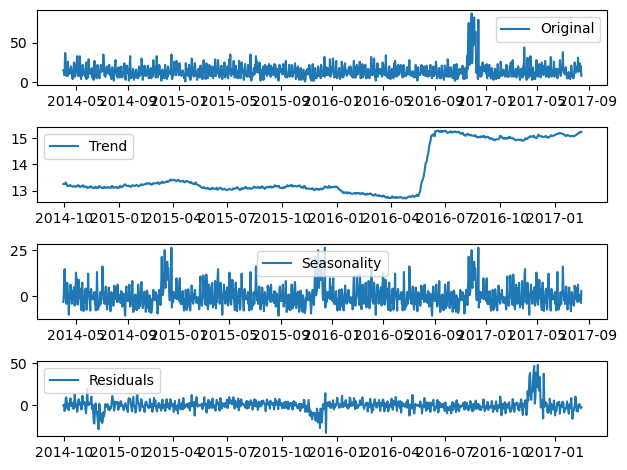

In [ ]:
# so the time series is stationary. suggest me what to do next

# decompose the time series
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(sampledf['unit_sales'], period=365)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.subplot(411)
plt.plot(sampledf['unit_sales'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


Observation: the seasonality seems to be strong in this one. SARIMAX has a chance to work

### Auto Correlation Function (ACF) and Partial Auto Correlation Function (PACF)

The next step is to determine the order of the ARIMA model.

We can do this by looking at the Auto Correlation Function (ACF) and Partial Auto Correlation Function (PACF) plots.

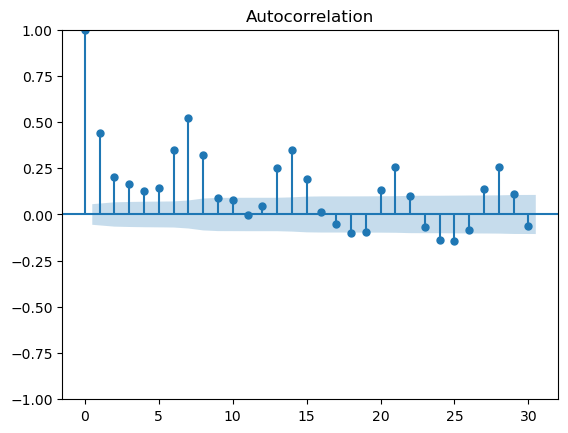

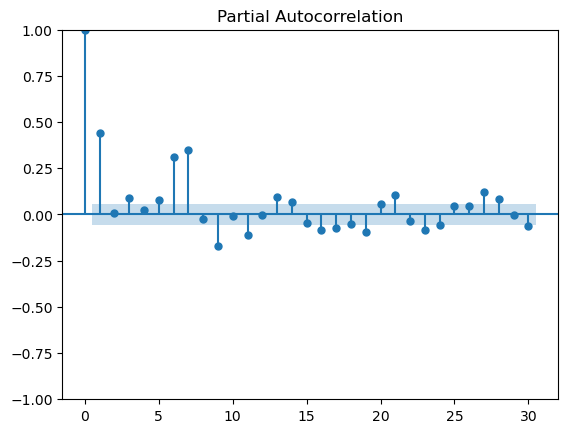

In [ ]:
# better way to plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_periods = 30

plot_acf(sampledf['unit_sales'], lags=acf_periods)
plot_pacf(sampledf['unit_sales'], lags=acf_periods)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

lag_acf = acf(sampledf['unit_sales'], nlags=acf_periods)
lag_pacf = pacf(sampledf['unit_sales'], nlags=acf_periods, method='ols')


acf_table = DataFrame(lag_acf)
acf_table.columns = ['ACF']
acf_table.index.name = 'Lag'
print(acf_table)


pacf_table = DataFrame(lag_pacf)
pacf_table.columns = ['PACF']
pacf_table.index.name = 'Lag'
print(pacf_table)

NameError: name 'DataFrame' is not defined

## ACF and PACF interpretation

### Non-Seasonal ARIMA Order (p, d, q)

Identify \( p \) and \( q \) from significant PACF and ACF spikes (lags 1 and 6-8), with \( d \) = 0 since the data is stationary.

### Seasonal ARIMA Order (P, D, Q, m)

Determine \( m \) from ACF patterns (weekly seasonality), with \( P \) and \( Q \) based on multiples of \( m \) in PACF/ACF, and \( D \) = 0.

### Resulting SARIMAX parameters

The resulting SARIMAX parameters are (p, d, q) = (1 or 2, 0, 1 or 2) for the non-seasonal part and (P, D, Q, m) = (1, 0, 1, 7) for the seasonal part.

In [ ]:
untuned_sarimax_order = (2, 0, 2)
untuned_sarimax_seasonal_order = (1, 0, 1, 7)

# SARIMAX Hyperparameter Tuning

We use pmdarima auto_arima to do the hyperparameter tuning.

It search by trying to adjust the parameters incrementally and use AIC to choose the best model.

AIC is a better metric to compare between regression models than MSE since it combine both fitness and complexity of the models.

In [ ]:
from pmdarima import auto_arima
tuned_auto_sarimax = auto_arima(sampledf.unit_sales, seasonal=True, m=7, stepwise=True, trace=True)

Performing stepwise search to minimize aic


 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=8099.139, Time=1.14 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=8819.911, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=8315.021, Time=0.22 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=8414.639, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=10383.431, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=8355.289, Time=1.05 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=8289.773, Time=0.86 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=inf, Time=2.23 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=8497.579, Time=0.52 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=8314.300, Time=1.99 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=inf, Time=1.70 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=inf, Time=2.76 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=8299.116, Time=0.88 sec
 ARIMA(2,0,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.98 sec
 ARIMA(3,0,2)(1,0,1)[7] intercept 

In [ ]:
print('SARIMAX parameters')
print(f'Untuned order={untuned_sarimax_order}, seasonal_order={untuned_sarimax_seasonal_order}')
print(f'Tuned order={tuned_auto_sarimax.order}, seasonal_order={tuned_auto_sarimax.seasonal_order}')

SARIMAX parameters
Untuned order=(2, 0, 2), seasonal_order=(1, 0, 1, 7)
Tuned order=(2, 0, 2), seasonal_order=(1, 0, 1, 7)


The tuned hyperparameter happen to be the same as our manual observation from ACF and PACF.

So we will use the tuned hyperparameter and won't run untuned model again since that won't let us see different information.

In [ ]:
from typing import Tuple
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_and_predict_sarimax(
        train_df: pandas.DataFrame,
        test_df: pandas.DataFrame,
        order: Tuple[int, int, int],
        seasonal_order: Tuple[int, int, int, int],
        forecast_steps:int=7
    ) -> tuple[SARIMAX, pandas.Series]:
    initial_traindf = train_df
    train_size = initial_traindf.shape[0]

    predictions = []
    target_iterations = math.ceil(test_df.shape[0] / forecast_steps)
    for i in range(target_iterations):
        traindf = sampledf.iloc[:train_size].copy()
        model = SARIMAX(traindf['unit_sales'], order=order, seasonal_order=seasonal_order, )
        results = model.fit(disp=0)

        pred = results.get_forecast(steps=forecast_steps).predicted_mean
        predictions.append(pred)


        train_size += forecast_steps

    tuned_sarimax_predict = pandas.concat(predictions)
    tuned_sarimax_predict = tuned_sarimax_predict.loc[tuned_sarimax_predict.index <= test_df.index.max()]

    return model, tuned_sarimax_predict





/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sammymy

sneak peak of SARIMAX prediction 

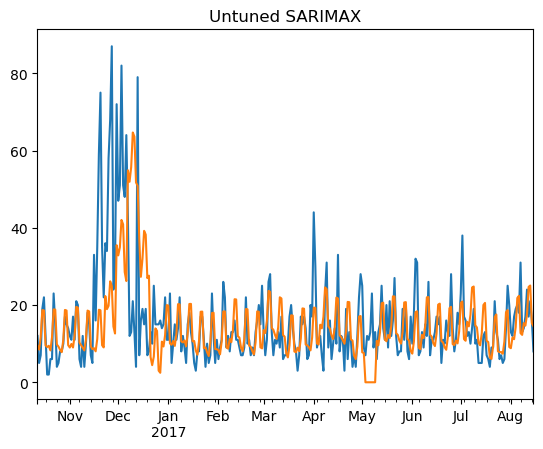

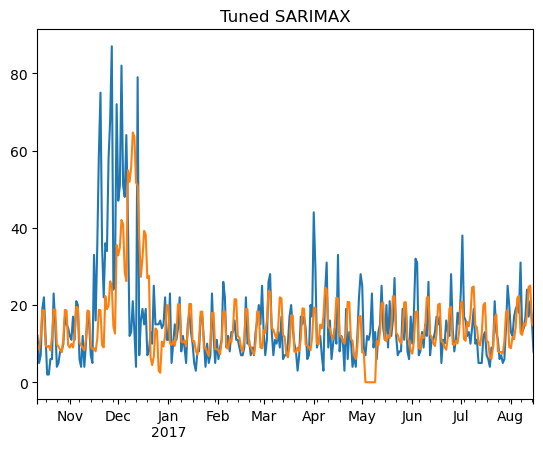

In [ ]:
untuned_sarimax_model, untuned_sarimax_predict = fit_and_predict_sarimax(train_df, test_df, untuned_sarimax_order, untuned_sarimax_seasonal_order)
tuned_sarimax_model, tuned_sarimax_predict = fit_and_predict_sarimax(train_df, test_df, tuned_auto_sarimax.order, tuned_auto_sarimax.seasonal_order)

test_df.unit_sales.plot()
untuned_sarimax_predict.plot()
plt.title('Untuned SARIMAX')
plt.show()

# plot tuned_sarimax_predict as a separate chart
test_df.unit_sales.plot()
tuned_sarimax_predict.plot()
plt.title('Tuned SARIMAX')
plt.show()

In [ ]:
def get_xgb_effective_columns() -> List[str]:
    global columns
    effective_columns = columns
    banned_columns = set([
        # 'dcoilwtico',
        # 'unit_sales_ma7_lag1',
        'unit_sales_ma30_lag1',
    ])
    effective_columns = [column for column in columns if column not in banned_columns]
    return effective_columns

In [ ]:
import xgboost as xgb

def fit_and_predict_xgb(
    model: xgb.XGBRegressor,
    train_df: pandas.DataFrame,
    test_df: pandas.DataFrame
) -> tuple[xgb.XGBRegressor, pandas.Series]:
    effective_columns = get_xgb_effective_columns()

    # split into train and test
    X_train = train_df[effective_columns].drop('unit_sales', axis=1)
    X_test = test_df[effective_columns].drop('unit_sales', axis=1)
    y_train = train_df['unit_sales']

    model.fit(X_train, y_train)

    # predict
    untuned_xgb_predict_values = model.predict(X_test)
    untuned_xgb_predict = pandas.Series(untuned_xgb_predict_values, index=test_df.index)

    return model, untuned_xgb_predict




In [ ]:
from sklearn.model_selection import GridSearchCV


def tune_xgb(
    model: xgb.XGBRegressor,
    sampledf: pandas.DataFrame,
    cv_splits: List[dict[str, Any]],
) -> xgb.XGBRegressor:
    gridsearch_splits = [
        [partition['tuning_train_index'], partition['tuning_validation_index']]
        for partition
        in cv_splits
    ]

    param_grid = {
        'max_depth': [3, 4, 5],
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.5, 0.7, 1],
        'colsample_bytree': [0.5, 0.7, 1],
    }

    effective_columns = get_xgb_effective_columns()

    
    xgb_grid_search = GridSearchCV(model, param_grid, cv=gridsearch_splits, n_jobs=-1, verbose=2)
    xgb_grid_search.fit(sampledf[effective_columns].drop('unit_sales', axis=1), sampledf['unit_sales'])

    print(xgb_grid_search.best_params_)
    print(xgb_grid_search.best_score_)
    print(xgb_grid_search.best_estimator_)

    tuned_xgb_model = xgb_grid_search.best_estimator_

    return tuned_xgb_model

base_xbg_model = xgb.XGBRegressor()
tuned_xgb_model = tune_xgb(base_xbg_model, sampledf, cv_splits)

NameError: name 'xgb' is not defined

sneak peak tuned xgboost prediction

In [ ]:
tuned_xgb_model, tuned_xgb_predict = fit_and_predict_xgb(tuned_xgb_model, train_df, test_df)


test_df.unit_sales.plot()
tuned_xgb_predict.plot()


NameError: name 'fit_and_predict_xgb' is not defined

In [ ]:
sneak peak untuned xgboost prediction

<Axes: >

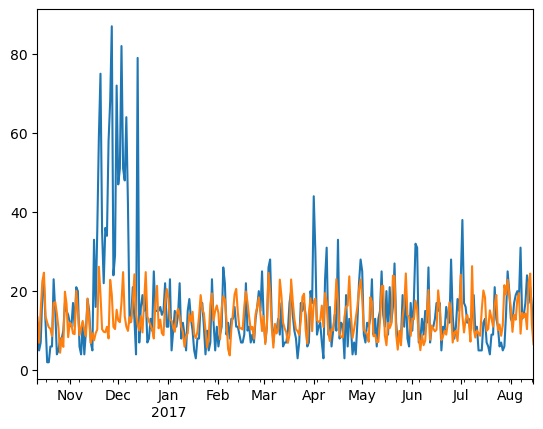

In [ ]:
model = xgb.XGBRegressor()
untuned_xgb_model, untuned_xgb_predict = fit_and_predict_xgb(model, train_df, test_df)

test_df.unit_sales.plot()
untuned_xgb_predict.plot()

# Baseline Model

We use moving average of 30 days as the baseline to see how well other models perform and provide added values.

In [ ]:
def fit_and_predict_ma30(train_df: pandas.DataFrame, test_df: pandas.DataFrame) -> tuple[Any, pandas.Series]:
    ma30_predict = test_df.unit_sales_ma30_lag1
    model = None
    return model, ma30_predict

# Ensemble Model

We ensemble the tuned SARIMAX and tuned XGBoost together.

The ensemble model is simple average of the two models.

In [ ]:
# import Any
from typing import Any

def fit_and_predict_ensemble(train_df: pandas.DataFrame, test_df: pandas.DataFrame) -> tuple[Any, pandas.Series]:
    global tuned_xgb_model, tuned_sarimax_model
    global tuned_auto_sarimax
    tuned_xgb_model, tuned_xgb_predict = fit_and_predict_xgb(tuned_xgb_model, train_df, test_df)
    tuned_sariamx_model, tuned_sarimax_predict = fit_and_predict_sarimax(train_df, test_df, tuned_auto_sarimax.order, tuned_auto_sarimax.seasonal_order)

    model = (tuned_xgb_model, tuned_sarimax_model)

    ensemble_predict = (tuned_xgb_predict + tuned_sarimax_predict) / 2

    return model, ensemble_predict

# Cross Validation

In [ ]:
cv_results = []

algorithms = {
    '1_ensemble': fit_and_predict_ensemble,
    '2_tuned_xgb': lambda train_df, test_df: fit_and_predict_xgb(tuned_xgb_model, train_df, test_df),
    '3_tuned_sarimax': lambda train_df, test_df: fit_and_predict_sarimax(train_df, test_df, tuned_auto_sarimax.order, tuned_auto_sarimax.seasonal_order),
    # 'untuned_sarimax': lambda train_df, test_df: fit_and_predict_sarimax(train_df, test_df, untuned_sarimax_order, untuned_sarimax_seasonal_order),
    '4_untuned_xgb': lambda train_df, test_df: fit_and_predict_xgb(untuned_xgb_model, train_df, test_df),
    '5_ma30_baseline': fit_and_predict_ma30,
    # '6_naive_baseline': fit_and_predict_naive,
    
}

evaluations = []

for fold in cv_splits:
    print('Processing Fold:', fold['fold'])

    train_df = sampledf.loc[sampledf.index[fold['train_index']]]
    test_df = sampledf.loc[sampledf.index[fold['test_index']]]

    fold_result = {
        'train': train_df,
        'test': test_df,
        'predictions': {},
    }
        
    for algorithm_name, fit_and_predict_fn in algorithms.items():
        print('Algorithm:', algorithm_name)

        model, predict = fit_and_predict_fn(train_df, test_df)

        fold_result[algorithm_name] = predict

        evaluation_item = {
            'fold': fold['fold'],
            'algorithm': algorithm_name,
        }

        evaluation_item['rmse'] = math.sqrt(((predict - test_df.unit_sales) ** 2).mean())
        evaluation_item['rmspe'] = math.sqrt((((predict - test_df.unit_sales) / test_df.unit_sales) ** 2).mean())
        # evaluation_item['mape'] = (abs(predict - test_df.unit_sales) / test_df.unit_sales).mean()

        evaluations.append(evaluation_item)

    cv_results.append(fold_result)



evaluationdf = pandas.DataFrame(evaluations)
evaluationdf


Processing Fold: 0
Algorithm: 1_ensemble


/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sammymy

Algorithm: 2_tuned_xgb
Algorithm: 3_tuned_sarimax


/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sammymy

Algorithm: 4_untuned_xgb
Algorithm: 5_ma30_baseline
Processing Fold: 1
Algorithm: 1_ensemble


...

/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.c

Algorithm: 2_tuned_xgb
Algorithm: 3_tuned_sarimax


/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/sammymymy/Desktop/sertis/.conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/sammymymy/Desktop/sertis/.c

Algorithm: 4_untuned_xgb
Algorithm: 5_ma30_baseline


,fold,algorithm,rmse
0,0,1_ensemble,5.011214
1,0,2_tuned_xgb,5.004981
2,0,3_tuned_sarimax,5.346586
3,0,4_untuned_xgb,6.056174
4,0,5_ma30_baseline,6.429957
5,1,1_ensemble,4.628359
6,1,2_tuned_xgb,4.722804
7,1,3_tuned_sarimax,4.641063
8,1,4_untuned_xgb,5.833159
9,1,5_ma30_baseline,6.261091


In [ ]:
# mean group by algorithm. sort by mean rmse

evaluationdf.groupby('algorithm').mean().sort_values('rmse')

,fold,rmse
algorithm,,
1_ensemble,1.0,7.013544
2_tuned_xgb,1.0,7.316085
3_tuned_sarimax,1.0,7.331950
4_untuned_xgb,1.0,8.136594
5_ma30_baseline,1.0,8.432996


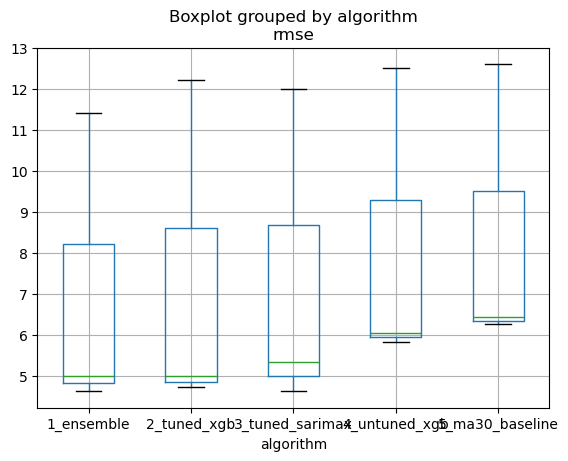

In [ ]:
# box plot of rmse by algorithm. sort by mean rmse
evaluationdf.boxplot(column='rmse', by='algorithm')
plt.show()

# Appendix A: Further Possible Improvements

### 1. Feature Engineering and Utilizing More External Data Sources
- There are many more features that can be engineered from the dataset. For example, holiday information is still not used due to time limit.
- We can use more external data sources. For example, we have geolocation data, we can utilize external mobility data in that area as features.
- We can notice that we remove the feature `unit_sales_ma30_lag1` from XGBoost training. Removing it has show a significant performance improvement. XGBoost can handle a large number of features, but feature selection can still improve performance. We can explore this if we have more time.

### 2. Utilizing More Recent Algorithms
There are many recent advancement in time series analysis. For examples:
- Facebook's Prophet (released 2017) and N-BEATS (released 2020) show exceptional performance in many competitions.
- Google's TimesFM (released February 2024), use large Transformer arhitecture that can learn complex patterns.

### 3. Improve The Ensemble Technique
Due to time limit, we choose a very simple ensemble technique, simple average.
While it's very simple, it perform well in many real world problems. We also saw that in our case.

However, there are other more advanced ensemble techniques unexplored in this take-home assignment.

### 4. Hierarchical Time Series Forecasting
There are hierarchical properties that we can utilize. It can help reduce the required computing power than doing single time series for 100,000 times. With the higher group level information, we can use to improve the result of cases where there is insufficient data for a lot of (store_nbr, item_nbr) pairs

# Appendix B: What's Equally Important To Accuracy

In real world data science projects, accuracy is not the only thing that matters.
A lot of times the customers are interested in the reasons behind the prediction so that they can improve their business from the source factors.
Sometimes, customers are not convinced if the reasons are not provided.

The good side of algorithms we have chosen is that they provide us the insights we need.
For example, here is the feature importance information from our XGBoost model.

The result indicate that day-of-week is the one of most important drive force behind the unit sales, especially Saturyday (dow5) and Sunday (dow6)

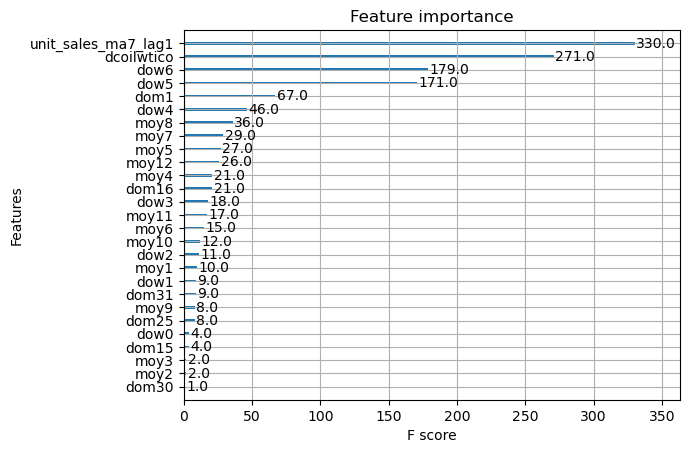

In [ ]:
xgb.plot_importance(tuned_xgb_model)
plt.show()

# Notebook Timing Summary

In [ ]:
end_time = datetime.datetime.now()
elapsed_time = end_time - start_time
print('End time', end_time)
print('Elapsed Time:', elapsed_time)

End time 2024-06-09 19:06:46.271117
Elapsed Time: 0:06:30.342992
